# Data preparation for US Stock Return Prediction
What we do here is to prepare the data for our machine learning project. First we collect data from CRSP, OSAP, and Goyal-Welch Predictor Data. Next step is to merge them to build a panel dataset.

The final output is one row per (permno, yyyymm) with 22 firm-level features, 8 interaction terms, and the return label.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Paths (relative to this notebook) ──────────────────────────────────────
DATA_DIR   = '.'                          # same directory as the notebook
CRSP_FILE  = os.path.join(DATA_DIR, 'crsp_msf_v2.csv')
SEC_FILE   = os.path.join(DATA_DIR, 'crsp_stksecurityinfohist.csv')
INTER_DIR  = os.path.join(DATA_DIR, 'intermediate')   # checkpoints
os.makedirs(INTER_DIR, exist_ok=True)

# ── Sample parameters ──────────────────────────────────────────────────────
SAMPLE_START = 197201    # yyyymm; CRSP data starts here
# SAMPLE_END is inferred from the data (most recent available)

# ── Random seed (for any downstream reproducibility) ───────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Configuration loaded.')
print(f'  DATA_DIR   : {os.path.abspath(DATA_DIR)}')
print(f'  INTER_DIR  : {os.path.abspath(INTER_DIR)}')
print(f'  Sample from: {SAMPLE_START}')

Configuration loaded.
  DATA_DIR   : /Users/quanzaixuan/Desktop/ML_Fin/ml_project_stk_prediction
  INTER_DIR  : /Users/quanzaixuan/Desktop/ML_Fin/ml_project_stk_prediction/intermediate
  Sample from: 197201


## Load and Inspect CRSP Data

We use two CRSP files in CIZ format:
- **crsp_msf_v2.csv** (`crsp_msf`): monthly stock file. One row per (permno, month-end date).
  Key columns: `PERMNO`, `MthCalDt`, `MthPrc`, `MthCap`, `MthRet`, `MthVol`, `ShrOut`.
- **crsp_stksecurityinfohist.csv** (`sec_info`): security-level attributes also at monthly granularity.
  Used for filtering (share type, exchange, issuer type).


We also convert the date string to a `yyyymm` integer key here, which is the merge key used by OSAP.

In [2]:
def load_crsp_monthly(filepath):
    df = pd.read_csv(filepath, parse_dates=['MthCalDt'])
    df.columns = df.columns.str.lower()
    df['yyyymm'] = df['mthcaldt'].dt.year * 100 + df['mthcaldt'].dt.month
    # The CIZ export can contain exact duplicate rows; drop them at source.
    n_before = len(df)
    df = df.drop_duplicates(subset=['permno', 'yyyymm'], keep='first')
    if len(df) < n_before:
        print(f'  load_crsp_monthly: dropped {n_before - len(df):,} duplicate rows')
    return df


def load_sec_info(filepath):
    df = pd.read_csv(filepath, parse_dates=['MthCalDt'])
    df.columns = df.columns.str.lower()
    df['yyyymm'] = df['mthcaldt'].dt.year * 100 + df['mthcaldt'].dt.month
    return df


crsp_raw = load_crsp_monthly(CRSP_FILE)
sec_raw  = load_sec_info(SEC_FILE)

print('=== crsp_msf_v2 (monthly stock file) ===')
print(f'Shape         : {crsp_raw.shape}')
print(f'Date range    : {crsp_raw["mthcaldt"].min().date()} to {crsp_raw["mthcaldt"].max().date()}')
print(f'Unique permno : {crsp_raw["permno"].nunique():,}')
print()
print('Dtypes:')
print(crsp_raw.dtypes)
print()
print('Missing values:')
print(crsp_raw.isnull().sum())
print()
print('Head:')
crsp_raw.head(3)

  load_crsp_monthly: dropped 51,002 duplicate rows


=== crsp_msf_v2 (monthly stock file) ===
Shape         : (4601560, 12)
Date range    : 1972-01-31 to 2025-12-31
Unique permno : 39,107

Dtypes:
permno               int64
hdrcusip            object
ticker              object
permco               int64
mthcaldt    datetime64[ns]
mthprc             float64
mthcap             float64
mthret             float64
mthretx            float64
mthvol             float64
shrout             float64
yyyymm               int64
dtype: object

Missing values:


permno           0
hdrcusip         0
ticker      102259
permco           0
mthcaldt         0
mthprc       78186
mthcap       80848
mthret       79967
mthretx      79967
mthvol      384990
shrout        2663
yyyymm           0
dtype: int64

Head:


,permno,hdrcusip,ticker,permco,mthcaldt,mthprc,mthcap,mthret,mthretx,mthvol,shrout,yyyymm
0,10000,68391610,OMFGA,7952,1986-01-31,4.3750,16100.0,0.707317,0.707317,177082.0,3680.0,198601
1,10000,68391610,OMFGA,7952,1986-02-28,3.2500,11960.0,-0.257143,-0.257143,82800.0,3680.0,198602
2,10000,68391610,OMFGA,7952,1986-03-31,4.4375,16330.0,0.365385,0.365385,107801.0,3680.0,198603


In [3]:
print('=== crsp_stksecurityinfohist (security info) ===')
print(f'Shape         : {sec_raw.shape}')
print(f'Date range    : {sec_raw["mthcaldt"].min().date()} to {sec_raw["mthcaldt"].max().date()}')
print(f'Unique permno : {sec_raw["permno"].nunique():,}')
print()
print('Categorical value counts:')
for col in ['sharetype', 'securitytype', 'issuertype', 'primaryexch']:
    print(f'  {col}:')
    print('  ', sec_raw[col].value_counts(dropna=False).to_dict())
print()
print('Head:')
sec_raw.head(3)

=== crsp_stksecurityinfohist (security info) ===
Shape         : (4652562, 11)
Date range    : 1972-01-31 to 2025-12-31
Unique permno : 39,107

Categorical value counts:
  sharetype:
   {'NS': 4250571, 'AD': 172062, 'SB': 147184, 'UG': 50045, nan: 31240, 'CE': 1460}
  securitytype:
   {'EQTY': 3896858, 'FUND': 719598, nan: 31240, 'DERV': 4866}
  issuertype:


 {'CORP': 3234579, 'ACOR': 1309831, 'REIT': 108152}
  primaryexch:
   {'Q': 2296936, 'N': 1420634, 'A': 475632, 'R': 305160, 'X': 94932, 'B': 59256, 'I': 12}

Head:


,permno,hdrcusip,primaryexch,issuertype,securitytype,sharetype,ticker,permco,siccd,mthcaldt,yyyymm
0,10000,68391610,Q,ACOR,EQTY,NS,OMFGA,7952,3990,1986-01-31,198601
1,10000,68391610,Q,ACOR,EQTY,NS,OMFGA,7952,3990,1986-02-28,198602
2,10000,68391610,Q,ACOR,EQTY,NS,OMFGA,7952,3990,1986-03-31,198603


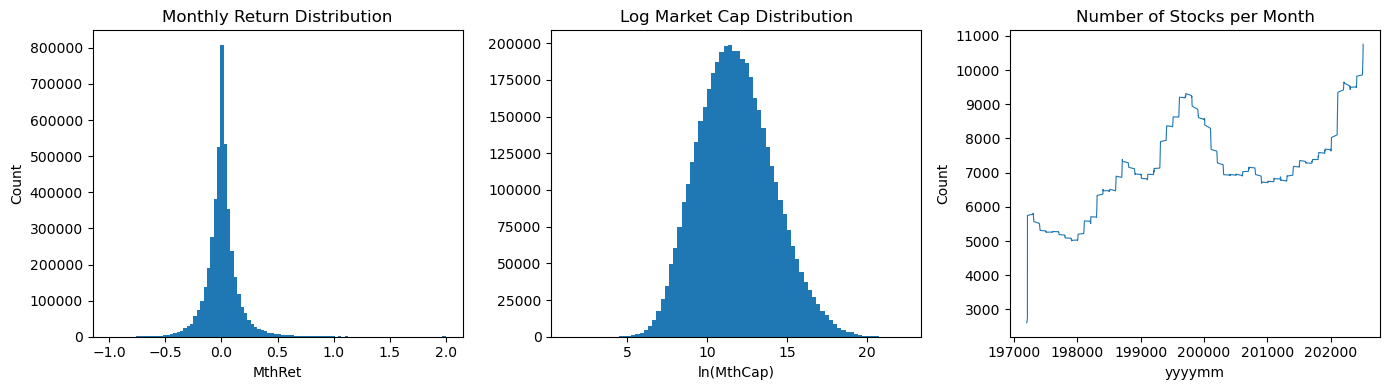

Figure saved to intermediate/


In [4]:
# --- Distribution plots for key CRSP variables ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Monthly return distribution (clip tails for readability)
ret_clipped = crsp_raw['mthret'].dropna().clip(-1, 2)
axes[0].hist(ret_clipped, bins=100, edgecolor='none')
axes[0].set_title('Monthly Return Distribution')
axes[0].set_xlabel('MthRet')
axes[0].set_ylabel('Count')

# Log market cap distribution
logcap = np.log(crsp_raw['mthcap'].dropna().replace(0, np.nan))
axes[1].hist(logcap, bins=80, edgecolor='none')
axes[1].set_title('Log Market Cap Distribution')
axes[1].set_xlabel('ln(MthCap)')

# Stock count over time
monthly_count = crsp_raw.groupby('yyyymm')['permno'].count()
axes[2].plot(monthly_count.index, monthly_count.values, linewidth=0.8)
axes[2].set_title('Number of Stocks per Month')
axes[2].set_xlabel('yyyymm')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(INTER_DIR, 'fig01_crsp_distributions.png'), dpi=120)
plt.show()
print('Figure saved to intermediate/')

---
## Filter Stock Universe

We restrict to ordinary common stocks listed on the three major US exchanges (NYSE, AMEX, NASDAQ).

**Filter criteria** (applied to the security info file, CIZ format codes):
| Field | Kept value(s) | Excluded |
|---|---|---|
| `ShareType` | `NS` (ordinary shares) | `AD` (ADRs), `SB`, `UG`, etc. |
| `SecurityType` | `EQTY` | `FUND` (ETFs/funds), `DERV`, etc. |
| `IssuerType` | `CORP` | `ACOR` (foreign private issuers), `REIT` |
| `PrimaryExch` | `N`, `A`, `Q` (NYSE, AMEX, NASDAQ) | `R`, `X`, `B` (regional/OTC) |

The security info file is already at monthly granularity (permno x month), so the filter is applied per month — stocks can enter and exit the universe as their attributes change.

After identifying qualifying (permno, yyyymm) pairs, we inner-join back to the CRSP monthly file.

In [5]:
VALID_EXCHANGES = {'N', 'A', 'Q'}


def filter_common_stock(sec_df):
    """
    Return a boolean mask for rows that are ordinary common stocks
    on NYSE / AMEX / NASDAQ.
    """
    mask = (
        (sec_df['sharetype']    == 'NS')   &
        (sec_df['securitytype'] == 'EQTY') &
        (sec_df['issuertype']   == 'CORP') &
        (sec_df['primaryexch'].isin(VALID_EXCHANGES))
    )
    return mask


# Identify qualifying (permno, yyyymm) pairs from the security info file
mask = filter_common_stock(sec_raw)
universe_keys = sec_raw.loc[mask, ['permno', 'yyyymm', 'primaryexch', 'siccd']].copy()

# The security info file can carry multiple rows per (permno, month) when a stock's
# classification changes mid-month. After filtering, only qualifying rows remain,
# but identical pairs can still exist. Deduplicate to keep the downstream merge 1-to-1.
n_before_dedup = len(universe_keys)
universe_keys = universe_keys.drop_duplicates(subset=['permno', 'yyyymm'], keep='first')
n_dropped = n_before_dedup - len(universe_keys)

print(f'Rows in sec_raw               : {len(sec_raw):>10,}')
print(f'Rows passing filter           : {mask.sum():>10,}')
print(f'Fraction retained             : {mask.mean():.1%}')
print(f'Duplicate keys dropped        : {n_dropped:>10,}')
print(f'Unique (permno, yyyymm) pairs : {len(universe_keys):>10,}')
print(f'Unique permno in universe     : {universe_keys["permno"].nunique():>10,}')
print(f'Date range                    : {universe_keys["yyyymm"].min()} to {universe_keys["yyyymm"].max()}')

Rows in sec_raw               :  4,652,562
Rows passing filter           :  2,961,051
Fraction retained             : 63.6%
Duplicate keys dropped        :     10,995
Unique (permno, yyyymm) pairs :  2,950,056
Unique permno in universe     :     21,423
Date range                    : 197201 to 202512


In [6]:
# Inner-join the monthly stock file to the filtered universe
crsp = crsp_raw.merge(
    universe_keys[['permno', 'yyyymm', 'primaryexch', 'siccd']],
    on=['permno', 'yyyymm'],
    how='inner'
)

# Apply sample start
crsp = crsp[crsp['yyyymm'] >= SAMPLE_START].reset_index(drop=True)

print('=== CRSP after universe filter and sample start ===')
print(f'Shape          : {crsp.shape}')
print(f'Date range     : {crsp["mthcaldt"].min().date()} to {crsp["mthcaldt"].max().date()}')
print(f'Unique permno  : {crsp["permno"].nunique():,}')
print(f'Unique months  : {crsp["yyyymm"].nunique():,}')
print()
print('Missing values:')
print(crsp.isnull().sum())
print()
print('Head:')
crsp.head(3)

=== CRSP after universe filter and sample start ===
Shape          : (2950056, 14)
Date range     : 1972-01-31 to 2025-12-31
Unique permno  : 21,423
Unique months  : 648

Missing values:


permno              0
hdrcusip            0
ticker           3285
permco              0
mthcaldt            0
mthprc           6293
mthcap           6304
mthret           7384
mthretx          7384
mthvol         116616
shrout             11
yyyymm              0
primaryexch         0
siccd               0
dtype: int64

Head:


,permno,hdrcusip,ticker,permco,mthcaldt,mthprc,mthcap,mthret,mthretx,mthvol,shrout,yyyymm,primaryexch,siccd
0,10001,36720410,GFGC,7953,1986-01-31,6.1250,6033.13,0.065217,0.065217,66740.0,985.0,198601,Q,4920
1,10001,36720410,GFGC,7953,1986-02-28,6.2500,6156.25,0.020408,0.020408,106700.0,985.0,198602,Q,4920
2,10001,36720410,GFGC,7953,1986-03-31,6.3125,6217.81,0.025352,0.010000,33541.0,985.0,198603,Q,4920


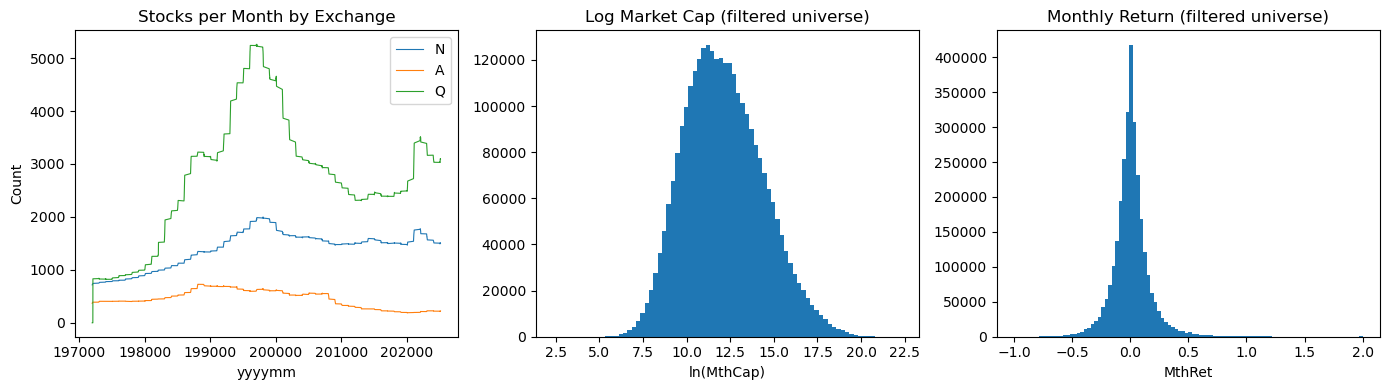

Checkpoint saved: intermediate/crsp_filtered.parquet


In [7]:
# --- Distribution plots after filtering ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Exchange breakdown
exch_counts = crsp.groupby(['yyyymm', 'primaryexch'])['permno'].count().unstack(fill_value=0)
for exch in ['N', 'A', 'Q']:
    if exch in exch_counts.columns:
        axes[0].plot(exch_counts.index, exch_counts[exch], label=exch, linewidth=0.8)
axes[0].set_title('Stocks per Month by Exchange')
axes[0].set_xlabel('yyyymm')
axes[0].set_ylabel('Count')
axes[0].legend()

# Log market cap after filter
logcap2 = np.log(crsp['mthcap'].dropna().replace(0, np.nan))
axes[1].hist(logcap2, bins=80, edgecolor='none')
axes[1].set_title('Log Market Cap (filtered universe)')
axes[1].set_xlabel('ln(MthCap)')

# Return distribution after filter
ret2 = crsp['mthret'].dropna().clip(-1, 2)
axes[2].hist(ret2, bins=100, edgecolor='none')
axes[2].set_title('Monthly Return (filtered universe)')
axes[2].set_xlabel('MthRet')

plt.tight_layout()
plt.savefig(os.path.join(INTER_DIR, 'fig02_universe_distributions.png'), dpi=120)
plt.show()

# Save the filtered CRSP panel as a checkpoint
crsp.to_parquet(os.path.join(INTER_DIR, 'crsp_filtered.parquet'), index=False)
print('Checkpoint saved: intermediate/crsp_filtered.parquet')


## CRSP-Derived Features

Four features are computed directly from the CRSP monthly panel because OSAP explicitly excludes them:

| Feature | Formula | Notes |
|---|---|---|
| `size` | ln(MthCap) | Firm size (log market equity) |
| `mom1m` | MthRet at t-1 | Short-term reversal; known as of month-end t |
| `price` | abs(MthPrc) | Price level (used as control / filter) |
| `turn` | MthVol / ShrOut | Monthly share turnover |

`mom1m` is constructed by shifting MthRet one period forward within each permno (i.e., aligning last month's return with the current row).
`turn` uses monthly aggregate volume from the CRSP monthly file as a proxy for average daily turnover.

In [8]:
def add_crsp_features(df):
    """Compute size, mom1m, price, and turnover in-place. Input must be sorted by permno, yyyymm."""
    df = df.sort_values(['permno', 'yyyymm']).copy()

    df['size']  = np.log(df['mthcap'].replace(0, np.nan))
    df['price'] = df['mthprc'].abs()

    # mom1m: previous month's return for same permno
    # consecutive months requirement is not enforced here; gaps produce NaN naturally
    df['mom1m'] = df.groupby('permno')['mthret'].shift(1)

    # turnover: monthly vol / shares outstanding (proxy for average daily turnover)
    df['turnover'] = df['mthvol'] / df['shrout'].replace(0, np.nan)

    return df


crsp = add_crsp_features(crsp)

CRSP_FEATURES = ['size', 'mom1m', 'price', 'turnover']

print('=== CRSP-derived features ===')
print(f'Shape: {crsp.shape}')
print()
print('Feature summary:')
print(crsp[CRSP_FEATURES].describe().T)
print()
print('Missing counts:')
print(crsp[CRSP_FEATURES].isnull().sum())

=== CRSP-derived features ===
Shape: (2950056, 18)

Feature summary:


              count        mean           std       min        25%        50%  \
size      2943752.0   12.131645      2.266919  2.357073  10.470605  11.967145   
mom1m     2921275.0    0.011144      0.195827 -0.995690  -0.068837   0.000000   
price     2943763.0   49.550108   3056.711902  0.006200   5.060000  13.080000   
turnover  2833440.0  217.902400  12504.856282  0.000000  24.670255  65.304266   

                 75%           max  
size       13.647694  2.231688e+01  
mom1m       0.072507  3.900000e+01  
price      26.937500  8.005400e+05  
turnover  152.083826  1.192257e+07  

Missing counts:
size          6304
mom1m        28781
price         6293
turnover    116616
dtype: int64


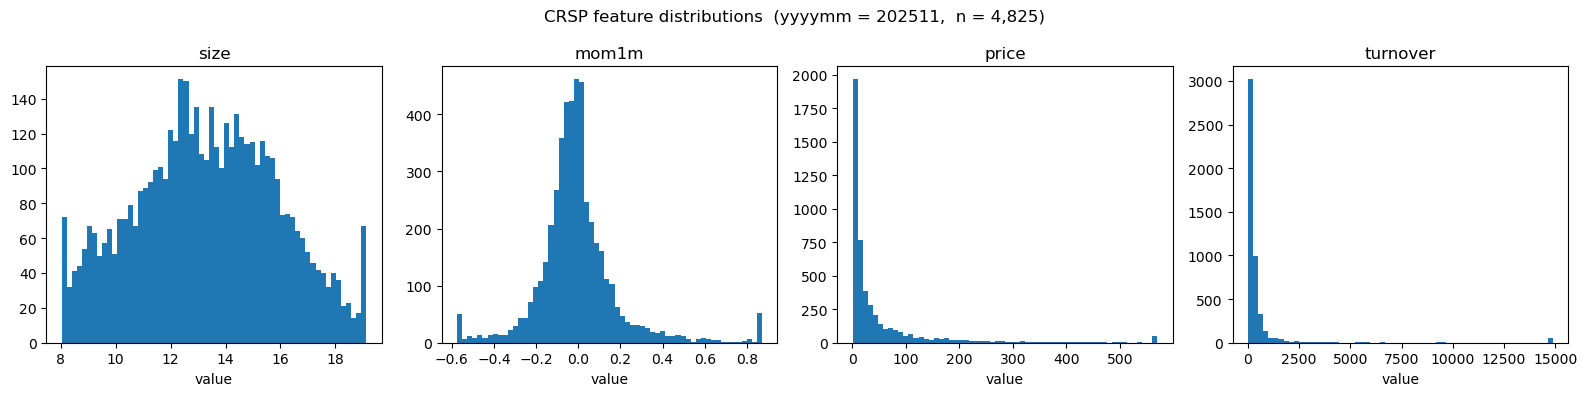

Checkpoint saved: intermediate/crsp_with_features.parquet  ((2950056, 18))


In [9]:
# --- Distributions of CRSP-derived features (one cross-section at a recent date) ---
snapshot_month = crsp['yyyymm'].max() - 1   # second most recent month for a complete cross-section
snap = crsp[crsp['yyyymm'] == snapshot_month]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'CRSP feature distributions  (yyyymm = {snapshot_month},  n = {len(snap):,})')

for ax, col in zip(axes, CRSP_FEATURES):
    data = snap[col].dropna()
    ax.hist(data.clip(data.quantile(0.01), data.quantile(0.99)), bins=60, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('value')

plt.tight_layout()
plt.savefig(os.path.join(INTER_DIR, 'fig03_crsp_features.png'), dpi=120)
plt.show()

# Checkpoint
crsp.to_parquet(os.path.join(INTER_DIR, 'crsp_with_features.parquet'), index=False)
print(f'Checkpoint saved: intermediate/crsp_with_features.parquet  ({crsp.shape})')

## OSAP Signals

We use the [Open Source Asset Pricing](https://www.openassetpricing.com/) library to pull 19 pre-computed signals
at the (permno, yyyymm) level. OSAP handles all Compustat/CRSP construction and data availability lags internally,
so no additional lag is applied here.


The download is cached to `intermediate/osap_signals.parquet`. The cache is automatically invalidated
when new signals are missing from it. Delete the file manually to force a full refresh.

In [10]:
import openassetpricing as oap
import pyarrow.parquet as pq

# Signals to download from OSAP (all have individual download URLs)
# sgr (annual sales growth) dropped: no individual URL, lives only in the 2.4 GB bulk zip
OSAP_SIGNALS = [
    'BM', 'EP', 'Mom12m', 'LRreversal', 'GP',
    'roaq',          # TODO: proxy for roeq (quarterly ROA, not quarterly ROE)
    'AssetGrowth', 'ShareIss1Y', 'Accruals', 'EarningsSurprise',
    'RealizedVol', 'IdioVol3F', 'Illiquidity', 'Beta', 'Leverage', 'PS',
    'IndMom',        # industry momentum (Moskowitz & Grinblatt 1999)
    'High52',        # 52-week high ratio (George & Hwang 2004)
    'RD',            # R&D intensity (Chan, Lakonishok & Sougiannis 2001)
]

# Rename map: OSAP acronym -> our feature name
OSAP_RENAME = {
    'BM'              : 'bm',
    'EP'              : 'ep',
    'Mom12m'          : 'mom12m',
    'LRreversal'      : 'mom36m',
    'GP'              : 'gross_profit',
    'roaq'            : 'roa_q',    # quarterly ROA (OSAP proxy; true target is quarterly ROE IBQ/CEQQ)
    'AssetGrowth'     : 'asset_growth',
    'ShareIss1Y'      : 'share_issuance',
    'Accruals'        : 'accruals',
    'EarningsSurprise': 'earn_surprise',
    'RealizedVol'     : 'ret_vol',
    'IdioVol3F'       : 'idio_vol',
    'Illiquidity'     : 'amihud_illiq',
    'Beta'            : 'beta',
    'Leverage'        : 'leverage',
    'PS'              : 'piotroski_f',
    'IndMom'          : 'ind_mom',
    'High52'          : 'high52',
    'RD'              : 'rd_intensity',
}

OSAP_CACHE = os.path.join(INTER_DIR, 'osap_signals.parquet')

def _need_download(cache_path, signals):
    """Return True if cache is missing or lacks any of the requested signals."""
    if not os.path.exists(cache_path):
        return True
    cached_cols = set(pq.read_schema(cache_path).names)   # schema-only, no data read
    missing = [s for s in signals if s not in cached_cols]
    if missing:
        print(f'  Cache missing signals {missing} — re-downloading.')
        return True
    return False

if _need_download(OSAP_CACHE, OSAP_SIGNALS):
    print('Downloading OSAP signals (this may take several minutes)...')
    ap = oap.OpenAP()
    osap_raw = ap.dl_signal('pandas', OSAP_SIGNALS)
    osap_raw.to_parquet(OSAP_CACHE, index=False)
    print(f'Downloaded and cached to {OSAP_CACHE}')
else:
    osap_raw = pd.read_parquet(OSAP_CACHE)
    print(f'Loaded OSAP signals from cache: {OSAP_CACHE}')

print(f'Shape: {osap_raw.shape}')
print(f'Columns: {osap_raw.columns.tolist()}')
print(f'yyyymm range: {osap_raw["yyyymm"].min()} to {osap_raw["yyyymm"].max()}')
print(f'Unique permno: {osap_raw["permno"].nunique():,}')

Loaded OSAP signals from cache: ./intermediate/osap_signals.parquet
Shape: (5359632, 21)
Columns: ['permno', 'yyyymm', 'BM', 'EP', 'Mom12m', 'LRreversal', 'GP', 'roaq', 'AssetGrowth', 'ShareIss1Y', 'Accruals', 'EarningsSurprise', 'RealizedVol', 'IdioVol3F', 'Illiquidity', 'Beta', 'Leverage', 'PS', 'IndMom', 'High52', 'RD']
yyyymm range: 192602 to 202610
Unique permno: 38,777


In [11]:
# Rename OSAP columns to our feature names
osap = osap_raw.rename(columns=OSAP_RENAME).copy()

# Cast keys to int64 to match CRSP dtypes
osap['permno'] = osap['permno'].astype('int64')
osap['yyyymm'] = osap['yyyymm'].astype('int64')

# Restrict to our sample period
osap = osap[osap['yyyymm'] >= SAMPLE_START].reset_index(drop=True)

OSAP_FEATURES = list(OSAP_RENAME.values())

print('=== OSAP signals after rename and sample filter ===')
print(f'Shape: {osap.shape}')
print()
print('Missing counts per signal:')
print(osap[OSAP_FEATURES].isnull().sum().to_string())
print()
print('Head:')
osap.head(3)

=== OSAP signals after rename and sample filter ===
Shape: (4721413, 21)

Missing counts per signal:


bm                2184054
ep                2720351
mom12m            1587366
mom36m            2123467
gross_profit      1947955
roa_q             2231580
asset_growth      1597844
share_issuance    1760186
accruals          1612952
earn_surprise     2481725
ret_vol            368332
idio_vol           368332
amihud_illiq      1022748
beta               927254
leverage          1902510
piotroski_f       4258140
ind_mom           1297935
high52             356759
rd_intensity      3328817

Head:


,permno,yyyymm,bm,ep,mom12m,mom36m,gross_profit,roa_q,asset_growth,share_issuance,...,earn_surprise,ret_vol,idio_vol,amihud_illiq,beta,leverage,piotroski_f,ind_mom,high52,rd_intensity
0,10000,198601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.065278,0.058618,NaN,NaN,NaN,NaN,0.147735,NaN,NaN
1,10000,198602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.031004,0.028526,NaN,NaN,NaN,NaN,0.172624,0.732394,NaN
2,10000,198603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.044548,0.042628,NaN,NaN,NaN,NaN,0.301842,1.000000,NaN


## Merge CRSP and OSAP

We left-join OSAP signals onto the filtered CRSP panel using (permno, yyyymm) as the key.
The CRSP panel is the master frame — every row that passed the universe filter is kept,
with OSAP columns set to NaN where coverage is absent.


In [12]:
panel = crsp.merge(osap, on=['permno', 'yyyymm'], how='left')

ALL_FEATURES = CRSP_FEATURES + OSAP_FEATURES

print('=== Panel after CRSP + OSAP merge ===')
print(f'Shape          : {panel.shape}')
print(f'Date range     : {panel["mthcaldt"].min().date()} to {panel["mthcaldt"].max().date()}')
print(f'Unique permno  : {panel["permno"].nunique():,}')
print(f'Unique months  : {panel["yyyymm"].nunique():,}')
print()
print('Feature coverage (non-null fraction per feature):')
coverage = panel[ALL_FEATURES].notna().mean().sort_values()
print(coverage.to_string())

=== Panel after CRSP + OSAP merge ===
Shape          : (2950056, 37)
Date range     : 1972-01-31 to 2025-12-31
Unique permno  : 21,423
Unique months  : 648

Feature coverage (non-null fraction per feature):


piotroski_f       0.128496
rd_intensity      0.413924
ep                0.587421
earn_surprise     0.683191
gross_profit      0.707123
bm                0.741727
mom36m            0.760963
roa_q             0.765889
accruals          0.780824
asset_growth      0.784319
leverage          0.832338
beta              0.851132
share_issuance    0.858313
amihud_illiq      0.862215
mom12m            0.904002
turnover          0.960470
high52            0.971579
ret_vol           0.973110
idio_vol          0.973110
ind_mom           0.979859
mom1m             0.990244
size              0.997863
price             0.997867


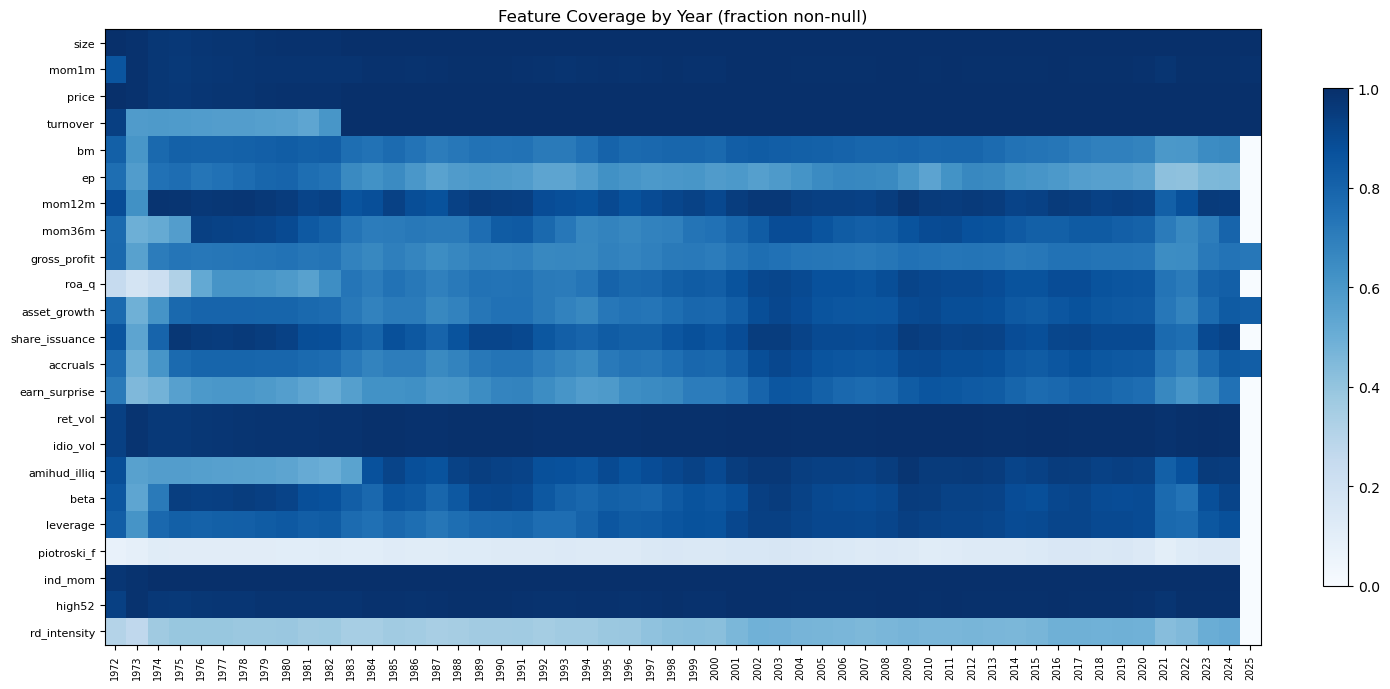

Checkpoint saved: intermediate/panel_raw.parquet


In [13]:
# --- Feature coverage over time (heatmap by decade) ---
# Count non-null fraction per feature per year
panel['year'] = panel['mthcaldt'].dt.year
coverage_yr = (
    panel.groupby('year')[ALL_FEATURES]
    .apply(lambda g: g.notna().mean())
)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(coverage_yr.T, aspect='auto', vmin=0, vmax=1, cmap='Blues')
ax.set_yticks(range(len(ALL_FEATURES)))
ax.set_yticklabels(ALL_FEATURES, fontsize=8)
ax.set_xticks(range(len(coverage_yr.index)))
ax.set_xticklabels(coverage_yr.index, rotation=90, fontsize=7)
ax.set_title('Feature Coverage by Year (fraction non-null)')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.savefig(os.path.join(INTER_DIR, 'fig04_feature_coverage.png'), dpi=120)
plt.show()

panel.drop(columns='year', inplace=True)

# Checkpoint
panel.to_parquet(os.path.join(INTER_DIR, 'panel_raw.parquet'), index=False)
print('Checkpoint saved: intermediate/panel_raw.parquet')

## Prediction Target (t+1 Return)

The label is `ret_fwd`: next month's total return for each stock.
It is constructed by shifting `mthret` one period backward within each permno group —
the return in row (permno, t) becomes the return at month t+1.


In [ ]:
# Sort once; all subsequent shift operations depend on this order
panel = panel.sort_values(['permno', 'yyyymm']).reset_index(drop=True)

# ret_fwd at time t = mthret at time t+1 for the same permno
panel['ret_fwd'] = panel.groupby('permno')['mthret'].shift(-1)



TARGET = 'ret_fwd'   # TODO: replace with ret_excess once rf data is available
print(f'Target variable: {TARGET}')
print()
print(f'ret_fwd non-null: {panel["ret_fwd"].notna().sum():,}  '
      f'({panel["ret_fwd"].notna().mean():.1%} of rows)')
print()
print('ret_fwd summary:')
print(panel['ret_fwd'].describe())

Target variable: ret_fwd

ret_fwd non-null: 2,922,274  (99.1% of rows)

ret_fwd summary:
count    2.922274e+06
mean     1.097608e-02
std      1.969594e-01
min     -1.000000e+00
25%     -6.896600e-02
50%      0.000000e+00
75%      7.246400e-02
max      3.900000e+01
Name: ret_fwd, dtype: float64


## Cross-Sectional Rank Normalization

Each feature is rank-normalized **within each month** across all stocks in the cross-section.
The mapping is linear from ranks to the interval [-1, 1]:

    normalized = 2 * (rank - 1) / (n - 1) - 1

where `n` is the number of non-missing observations in that month.
NaN values are preserved as NaN (they do not affect the ranking of other stocks).

This normalization removes the influence of extreme outliers and makes features comparable
across different scales and time periods — a standard step before feeding into linear models and logit.

In [15]:
# Cross-sectional rank normalization removed — using raw features only.
normed_features = []  # kept for compatibility; no _n columns are generated
print('Rank normalization skipped.')

Rank normalization skipped.


In [16]:
# Normalization distribution plot skipped (no _n columns).

## Interaction Terms

Twelve interaction terms are constructed from the cross-sectionally normalized features.

**Feature x feature interactions** (3 terms): multiply two normalized firm-level signals.
These capture non-linear economic relationships relevant for linear/logit models
(tree models learn interactions automatically).

| Interaction | Formula | Economic rationale |
|---|---|---|
| `bm_x_size` | bm_n * size_n | Value premium concentrated among small stocks |
| `mom12m_x_retvol` | mom12m_n * retvol_n | High-volatility momentum is fragile (momentum crash) |
| `agr_x_bm` | agr_n * bm_n | Investment effect varies with valuation level |

**Macro x feature interactions** (9 terms): multiply a normalized firm signal by a macro predictor.
Macro variables (tbl, tms, dfy from Welch-Goyal) are market-wide and time-varying — they are
the **same for all stocks in a given month**, so cross-sectional normalization is not applied to them.
Instead, they are used directly as scalars that shift the cross-sectional pricing of each factor.


In [17]:
# ── Load Goyal-Welch macro variables ────────────────────────────────────────
MACRO_FILE = os.path.join(DATA_DIR, 'PredictorData2025_goyal.xlsx')
macro = pd.read_excel(MACRO_FILE, sheet_name='Monthly', usecols=['yyyymm', 'tbl', 'lty', 'AAA', 'BAA', 'Rfree'])
macro['yyyymm'] = macro['yyyymm'].astype('int64')
macro['tms'] = macro['lty'] - macro['tbl']   # term spread = long-term yield - T-bill
macro['dfy'] = macro['BAA'] - macro['AAA']   # default yield spread = BAA - AAA
macro = macro[['yyyymm', 'tbl', 'tms', 'dfy', 'Rfree']]
macro = macro[macro['yyyymm'] >= SAMPLE_START].reset_index(drop=True)

panel = panel.merge(macro, on='yyyymm', how='left')

print(f'Macro data merged: {macro.shape}  range {macro.yyyymm.min()}~{macro.yyyymm.max()}')
print('Missing after merge:', panel[['tbl','tms','dfy','Rfree']].isnull().sum().to_dict())
print()

# bm is log(BE/ME); stocks with zero/negative book equity produce -inf → replace with NaN
panel['bm'] = panel['bm'].replace(-np.inf, np.nan)

# ── Feature x macro interactions ─────────────────────────────────────────────
# firm-level normalized signal × macro scalar (same value for all stocks in month t)
# Captures how factor premia vary with the macro/credit environment
for feat in ['bm', 'mom12m', 'beta']:
    for macro_var in ['tbl', 'tms', 'dfy']:
        panel[f'{feat}_{macro_var}'] = panel[feat] * panel[macro_var]

MACRO_INTERACTIONS = [
    'bm_tbl',     'bm_tms',     'bm_dfy',
    'mom12m_tbl', 'mom12m_tms', 'mom12m_dfy',
    'beta_tbl',   'beta_tms',   'beta_dfy',
]

ALL_INTERACTIONS = MACRO_INTERACTIONS
print('Macro interactions constructed:', ALL_INTERACTIONS)
print(panel[MACRO_INTERACTIONS].describe().T[['mean','std','min','max']])

Macro data merged: (648, 5)  range 197201~202512
Missing after merge: {'tbl': 0, 'tms': 0, 'dfy': 0, 'Rfree': 0}

Macro interactions constructed: ['bm_tbl', 'bm_tms', 'bm_dfy', 'mom12m_tbl', 'mom12m_tms', 'mom12m_dfy', 'beta_tbl', 'beta_tms', 'beta_dfy']


                mean       std       min        max
bm_tbl     -0.028739  0.049411 -1.144782   0.527354
bm_tms     -0.015305  0.027138 -0.387475   0.256347
bm_dfy     -0.007954  0.011496 -0.217762   0.087194
mom12m_tbl  0.005470  0.039084 -0.124751  24.847349
mom12m_tms  0.003071  0.020107 -0.546009   4.283803
mom12m_dfy  0.001057  0.007801 -0.033602   3.013123
beta_tbl    0.042124  0.046894 -0.669000   2.610540
beta_tms    0.020666  0.024714 -0.452018   1.277471
beta_dfy    0.010879  0.009046 -0.250128   0.642414


## Final Panel, Sanity Checks, and Save

We select the final set of columns, run sanity checks, and write the panel to a parquet file.

**Rows dropped**:
- Rows where `ret_fwd` is NaN (last observation of each stock — no next-month return to predict).
  These cannot be used for training or evaluation.

**Rows kept with NaN features**: rows where some signals are NaN are retained.
The models handle missing features differently (imputation vs. masking), which is left to the modeling notebook.

In [18]:
# ── Assemble final column list ───────────────────────────────────────────────
ID_COLS      = ['permno', 'yyyymm', 'mthcaldt', 'primaryexch', 'siccd']
RAW_FEATURES = ALL_FEATURES
MACRO_COLS   = ['tbl', 'tms', 'dfy', 'Rfree']
INTERACTIONS = ALL_INTERACTIONS
LABEL_COLS   = ['mthret']

final_cols = ID_COLS + RAW_FEATURES + MACRO_COLS + INTERACTIONS + LABEL_COLS
final = panel[final_cols].copy()

# ── Sanity checks ────────────────────────────────────────────────────────────
print('=== Sanity Checks ===')
print(f'Shape          : {final.shape}')
print(f'Date range     : {final["mthcaldt"].min().date()} to {final["mthcaldt"].max().date()}')
print(f'Unique permno  : {final["permno"].nunique():,}')
print(f'Unique months  : {final["yyyymm"].nunique():,}')
print()

dups = final.duplicated(subset=['permno', 'yyyymm']).sum()
print(f'Duplicate (permno, yyyymm) rows : {dups}  (should be 0)')
print()

print('Missing rate per feature (raw, sorted):')
miss_rate = final[RAW_FEATURES].isnull().mean().sort_values(ascending=False)
print(miss_rate.to_string())
print()

print('Macro columns missing:')
print(final[MACRO_COLS].isnull().sum().to_string())

=== Sanity Checks ===
Shape          : (2950056, 42)
Date range     : 1972-01-31 to 2025-12-31
Unique permno  : 21,423
Unique months  : 648

Duplicate (permno, yyyymm) rows : 0  (should be 0)

Missing rate per feature (raw, sorted):


piotroski_f       0.871504
rd_intensity      0.586076
ep                0.412579
earn_surprise     0.316809
gross_profit      0.292877
bm                0.258282
mom36m            0.239037
roa_q             0.234111
accruals          0.219176
asset_growth      0.215681
leverage          0.167662
beta              0.148868
share_issuance    0.141687
amihud_illiq      0.137785
mom12m            0.095998
turnover          0.039530
high52            0.028421
ret_vol           0.026890
idio_vol          0.026890
ind_mom           0.020141
mom1m             0.009756
size              0.002137
price             0.002133

Macro columns missing:
tbl      0
tms      0
dfy      0
Rfree    0


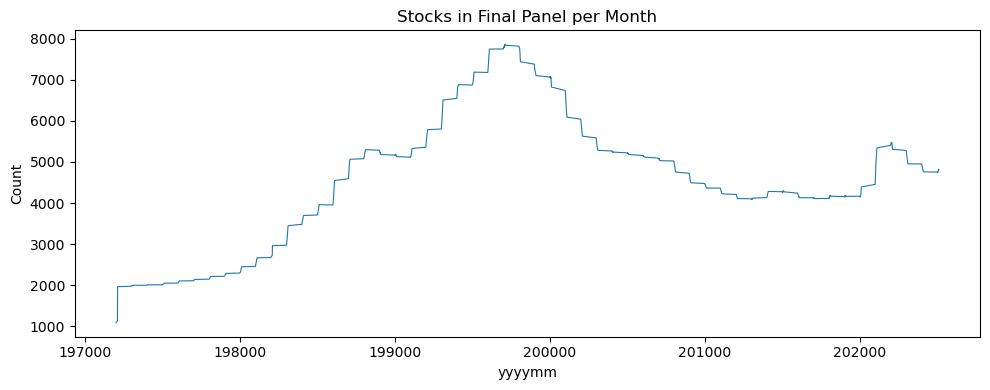

Final panel saved to: ./panel_features.parquet
Shape: (2950056, 42)

Column groups:
  ID columns        : 5
  Raw features      : 23
  Macro columns     : 4
  Interaction terms : 9
  Label columns     : 1


In [19]:
# --- Final panel: stock count over time ---
fig, ax = plt.subplots(figsize=(10, 4))
stock_count = final.groupby('yyyymm')['permno'].count()
ax.plot(stock_count.index, stock_count.values, linewidth=0.8)
ax.set_title('Stocks in Final Panel per Month')
ax.set_xlabel('yyyymm')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(INTER_DIR, 'fig06_final_panel.png'), dpi=120)
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────────
OUT_PATH = os.path.join(DATA_DIR, 'panel_features.parquet')
final.to_parquet(OUT_PATH, index=False)
print(f'Final panel saved to: {OUT_PATH}')
print(f'Shape: {final.shape}')
print()
print('Column groups:')
print(f'  ID columns        : {len(ID_COLS)}')
print(f'  Raw features      : {len(RAW_FEATURES)}')
print(f'  Macro columns     : {len(MACRO_COLS)}')
print(f'  Interaction terms : {len(INTERACTIONS)}')
print(f'  Label columns     : {len(LABEL_COLS)}')